# COVID-19 Bangladesh — EDA and Daily Cases Prediction

**Author:** Mohammad Sahadat Hossain  
**Description:** This notebook performs Exploratory Data Analysis (EDA) and forecasting on COVID-19 data for Bangladesh.



## Part 1: Data Scraping (Original R Code — Keep As Is)

> **How to run:** Either install `rpy2` and use the `%%R` magic cell below, or copy this code into an R / RStudio session, export the resulting dataframe to CSV (`write.csv(df, "covid_bd_raw.csv", row.names=FALSE)`), and then load it in Part 2 Python cells.

```r
# ── R scraping code (original) ──────────────────────────────────────────────
library(htmltab)
library(tidyverse)
library(ggplot2)
library(plotly)
library(prophet)
library(lubridate)
library(XML)
library(httr)
library(tidyquant)

url <- 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
r   <- GET(url)
doc <- readHTMLTable(doc = content(r, "text"))
names(doc)

df  <- htmltab("https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh", 10)
df
dim(df)
```

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIONAL: Run the R scraping code using rpy2 magic
# Uncomment the lines below if rpy2 is installed:
#   pip install rpy2
# ─────────────────────────────────────────────────────────────────────────────

# %load_ext rpy2.ipython

# %%R
# library(htmltab)
# library(httr)
# library(XML)
# url <- 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
# r   <- GET(url)
# doc <- readHTMLTable(doc = content(r, "text"))
# names(doc)
# df  <- htmltab("https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh", 10)
# write.csv(df, "covid_bd_raw.csv", row.names = FALSE)

## Part 2: Python Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
# Option A: If you ran the R scraping code and saved a CSV:
#   df_raw = pd.read_csv("covid_bd_raw.csv")
#
# Option B (default): Python-based scraping equivalent to R's htmltab(..., 10)
#   pandas.read_html scrapes all tables; index 9 = 10th table (0-based)

url = 'https://en.wikipedia.org/wiki/COVID-19_pandemic_in_Bangladesh'
tables = pd.read_html(url, header=0)
print(f"Total tables found: {len(tables)}")

# Inspect tables to find the statistics table (same as R's table index 10)
for i, t in enumerate(tables):
    print(f"Table {i}: shape={t.shape}, cols={list(t.columns[:4])}")


In [ ]:
# Select the daily statistics table (adjust index if Wikipedia has changed)
# R used htmltab(..., 10) → 10th table → Python index 9
# If that doesn't match, scan the output above and update TABLE_IDX
TABLE_IDX = 9

df_raw = tables[TABLE_IDX].copy()
print("Shape:", df_raw.shape)
df_raw.head()


In [19]:
df = pd.read_csv('/content/COVID-19 Dataset Bangladesh.csv')
print("Data loaded successfully. Shape:", df_covid.shape)

Data loaded successfully. Shape: (340, 12)


## Part 3: Data Cleaning & Preprocessing



In [20]:
import re

def clean_names(df):
    """Equivalent to janitor::clean_names() in R."""
    df = df.copy()
    df.columns = (
        df.columns
          .str.lower()
          .str.strip()
          .str.replace(r'[\s/\(\)\[\]]+', '_', regex=True)
          .str.replace(r'[^a-z0-9_]', '', regex=True)
          .str.strip('_')
    )
    return df

df = clean_names(df_raw)
df.head()


,unnamed_0,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,1,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,3,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,4,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,5,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [21]:
# Map whatever columns came back from Wikipedia to the expected names.
# Adjust the mapping below if your column names differ.

col_map = {}
cols = df.columns.tolist()

# Helper: find a column whose name contains a keyword
def find_col(keyword):
    matches = [c for c in cols if keyword.lower() in c.lower()]
    return matches[0] if matches else None

col_map[find_col('date')]      = 'date'
col_map[find_col('total') and find_col('tested') or find_col('cumul') and find_col('test') or find_col('total_test')] = 'total_tested'

# Build a safe rename dict (skip None keys)
rename_dict = {}
for raw, clean in col_map.items():
    if raw and raw in df.columns:
        rename_dict[raw] = clean

# Print current columns for reference
print("Current columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i}] {c}")


Current columns:
  [0] unnamed_0
  [1] date
  [2] total_tested
  [3] total_cases
  [4] total_deaths
  [5] total_recovered
  [6] in_the_last_24_hours_newly_tested
  [7] in_the_last_24_hours_new_cases
  [8] in_the_last_24_hours_new_deaths
  [9] in_the_last_24_hours_newly_recovered
  [10] day_of_pandemic
  [11] day_of_outbreak


In [23]:
# The `clean_names` function has already processed the column names.
# Based on df_raw inspection, an 'unnamed_0' column is often present
# from `pd.read_html` if the table has an index column.
# We will drop this `unnamed_0` column, as it's not data.

if 'unnamed_0' in df.columns:
    df = df.drop(columns=['unnamed_0'])

df.head()

,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [24]:
# ── Parse date column (equivalent to lubridate::ymd) ─────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# ── Fix specific cells — R: df[12,2]<-433  and  df[12,6]<-36 ────────────────
#    (row index 11 in Python because 0-based; col positions 1 and 5)
#    Mapping to column names: total_tested and in_the_last_24_hours_newly_tested
df.loc[11, 'total_tested'] = 433
df.loc[11, 'in_the_last_24_hours_newly_tested'] = 36

# ── Fill NA in daily-change columns with 0 (R: if_else(is.na(...), "0", ...)) ─
daily_cols = [
    'in_the_last_24_hours_newly_tested',
    'in_the_last_24_hours_new_cases',
    'in_the_last_24_hours_new_deaths',
    'in_the_last_24_hours_newly_recovered',
]
df[daily_cols] = df[daily_cols].fillna('0')

# ── Split day_of_pandemic_outbreak into two columns ───────────────────────────
#    The Python data scraping results in 'day_of_pandemic' and 'day_of_outbreak'
#    already as separate columns, unlike the R `htmltab` output.
#    Therefore, the splitting step from the original R code is not needed.
#    The following commented-out lines are removed:
#
# df[['day_of_pandemic', 'day_of_outbreak']] = (
#     df['day_of_pandemic_outbreak']
#       .astype(str)
#       .str.split('/', expand=True)
#       .iloc[:, :2]
# )
# df.drop(columns=['day_of_pandemic_outbreak'], inplace=True)


# ── Fix first rows (R: df[1,10]<-0  and  df[1:3,11]<-0) ─────────────────────
#    These are corrections to specific values in the 'day_of_pandemic' and 'day_of_outbreak' columns.
df.loc[df.index[0], 'day_of_pandemic'] = 0
df.loc[df.index[0:3], 'day_of_outbreak'] = 0

df.head()

,date,total_tested,total_cases,total_deaths,total_recovered,in_the_last_24_hours_newly_tested,in_the_last_24_hours_new_cases,in_the_last_24_hours_new_deaths,in_the_last_24_hours_newly_recovered,day_of_pandemic,day_of_outbreak
0,2020-03-08,111,3,0,0,111,3,0,0,0,0
1,2020-03-11,142,3,0,2,31,0,0,2,1,0
2,2020-03-12,163,3,0,2,21,0,0,0,2,0
3,2020-03-13,187,3,0,2,24,0,0,0,3,1
4,2020-03-14,211,5,0,3,24,2,0,1,4,2


In [27]:
# ── Convert all non-date columns to numeric (strip commas first) ──────────────

non_date_cols = [c for c in df.columns if c != 'date']
for col in non_date_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

# ── Drop rows with any NA ──
df = df.dropna().reset_index(drop=True)
print("Shape after na.omit:", df.shape)

# ── Recalculate daily-change columns from cumulative totals ───────────────────
df['in_the_last_24_hours_newly_tested']    = df['total_tested'].diff()
df['in_the_last_24_hours_new_cases']       = df['total_cases'].diff()
df['in_the_last_24_hours_new_deaths']      = df['total_deaths'].diff()
df['in_the_last_24_hours_newly_recovered'] = df['total_recovered'].diff()

# ── Set first row daily values = cumulative values ─
df.loc[0, 'in_the_last_24_hours_newly_tested']    = df.loc[0, 'total_tested']
df.loc[0, 'in_the_last_24_hours_new_cases']       = df.loc[0, 'total_cases']
df.loc[0, 'in_the_last_24_hours_new_deaths']      = df.loc[0, 'total_deaths']
df.loc[0, 'in_the_last_24_hours_newly_recovered'] = df.loc[0, 'total_recovered']

print(df.dtypes)


Shape after na.omit: (340, 11)
date                                    datetime64[ns]
total_tested                                     int64
total_cases                                      int64
total_deaths                                     int64
total_recovered                                  int64
in_the_last_24_hours_newly_tested              float64
in_the_last_24_hours_new_cases                 float64
in_the_last_24_hours_new_deaths                float64
in_the_last_24_hours_newly_recovered           float64
day_of_pandemic                                  int64
day_of_outbreak                                  int64
dtype: object


## Part 4: Exploratory Data Analysis (EDA)
### Train / Validation / Test Region Plot


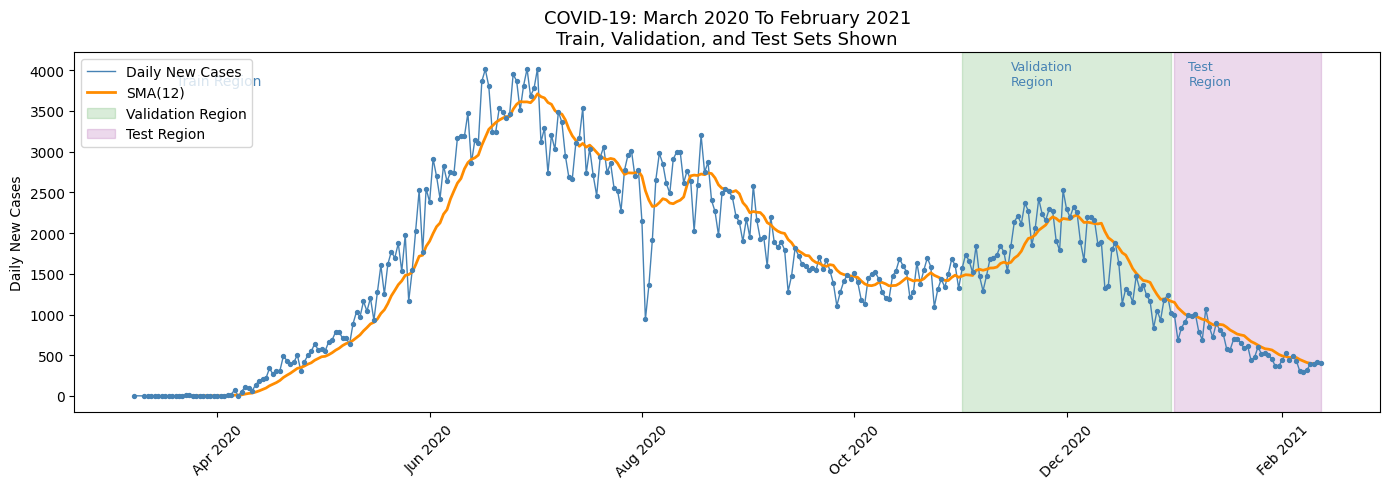

In [28]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

# ── Data line & points ────────────────────────────────────────────────────────
ax.plot(df['date'], df['in_the_last_24_hours_new_cases'],
        color='steelblue', linewidth=1, label='Daily New Cases')
ax.scatter(df['date'], df['in_the_last_24_hours_new_cases'],
           color='steelblue', s=8, zorder=3)

# ── 12-day Simple Moving Average (R: geom_ma(SMA, n=12)) ────────────────────
sma12 = df['in_the_last_24_hours_new_cases'].rolling(window=12).mean()
ax.plot(df['date'], sma12, color='darkorange', linewidth=2, label='SMA(12)')

# ── Shaded regions ────────────────────────────────────────────────────────────
val_start  = pd.Timestamp('2020-11-01')
val_end    = pd.Timestamp('2020-12-31')
test_start = pd.Timestamp('2021-01-01')
test_end   = pd.Timestamp('2021-02-12')

ax.axvspan(val_start,  val_end,  alpha=0.15, color='green',  label='Validation Region')
ax.axvspan(test_start, test_end, alpha=0.15, color='purple', label='Test Region')

# ── Annotations ──────────────────────────────────────────────────────────────
train_x = pd.Timestamp('2020-03-20')
ax.text(train_x, df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Train Region', color='steelblue', fontsize=10)
ax.text(pd.Timestamp('2020-11-15'),
        df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Validation\nRegion', color='steelblue', fontsize=9)
ax.text(pd.Timestamp('2021-01-05'),
        df['in_the_last_24_hours_new_cases'].max() * 0.95,
        'Test\nRegion', color='steelblue', fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title('COVID-19: March 2020 To February 2021\nTrain, Validation, and Test Sets Shown',
             fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Daily New Cases')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Interactive Daily New Cases Plot

In [29]:
fig_cases = px.line(
    df, x='date', y='in_the_last_24_hours_new_cases',
    title='Daily Cases of COVID-19 Patient<br><sup>From March 2020 to end of data</sup>',
    labels={'in_the_last_24_hours_new_cases': 'Daily Cases', 'date': 'Date'}
)
fig_cases.update_traces(line_color='steelblue')
fig_cases.update_layout(template='plotly_white', height=450)
fig_cases.show()


### Interactive Daily New Deaths by Day of Pandemic

In [30]:
fig_deaths = px.line(
    df, x='day_of_pandemic', y='in_the_last_24_hours_new_deaths',
    title='Daily New Deaths vs Day of Pandemic',
    labels={
        'day_of_pandemic': 'Day of Pandemic',
        'in_the_last_24_hours_new_deaths': 'Daily New Deaths'
    }
)
fig_deaths.update_traces(line_color='crimson')
fig_deaths.update_layout(template='plotly_white', height=420)
fig_deaths.show()


## Part 5: Prophet Forecasting
### 5.1 — Total Cases Forecast (30 days)

In [31]:
def run_prophet(df, date_col, value_col, periods=30, title=''):
    """
    Fit a Prophet model, plot forecast and components,
    and plot predicted vs actual for the training period.
    Equivalent to R's prophet() + dyplot.prophet() + prophet_plot_components().
    """
    dts = df[[date_col, value_col]].rename(columns={date_col: 'ds', value_col: 'y'})
    dts = dts.dropna()

    model = Prophet()
    model.fit(dts)

    future   = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # ── Interactive forecast plot ─────────────────────────────────────────────
    fig_fc = go.Figure()
    fig_fc.add_trace(go.Scatter(x=dts['ds'], y=dts['y'],
                                mode='markers', name='Actual',
                                marker=dict(color='black', size=4)))
    fig_fc.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'],
                                mode='lines', name='Forecast',
                                line=dict(color='steelblue')))
    fig_fc.add_trace(go.Scatter(
        x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
        y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
        fill='toself', fillcolor='rgba(70,130,180,0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Uncertainty'))
    fig_fc.update_layout(title=f'Prophet Forecast — {title}',
                         xaxis_title='Date', yaxis_title=value_col,
                         template='plotly_white', height=430)
    fig_fc.show()

    # ── Components plot (trend + weekly + yearly) ─────────────────────────────
    model.plot_components(forecast)
    plt.suptitle(f'Forecast Components — {title}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Predicted vs Actual scatter (in-sample) ───────────────────────────────
    n = len(dts)
    pre  = forecast['yhat'].iloc[:n].values
    act  = dts['y'].values

    fig2, ax2 = plt.subplots(figsize=(6, 5))
    ax2.scatter(pre, act, alpha=0.5, color='steelblue', s=20)
    m_coef, b_coef = np.polyfit(pre, act, 1)
    x_line = np.linspace(pre.min(), pre.max(), 100)
    ax2.plot(x_line, m_coef * x_line + b_coef, color='blue', linewidth=1.5)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_title(f'Predicted vs Actual — {title}')
    plt.tight_layout()
    plt.show()

    return model, forecast


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


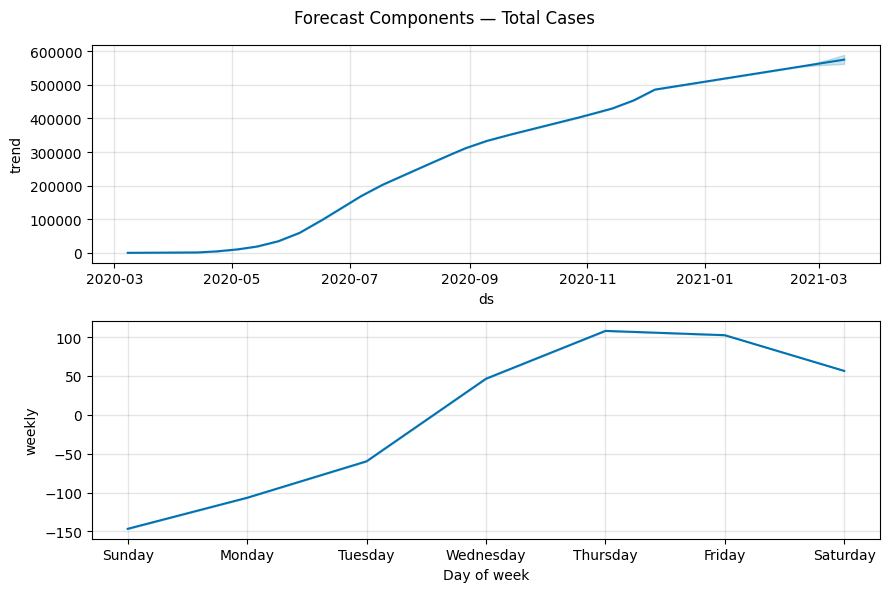

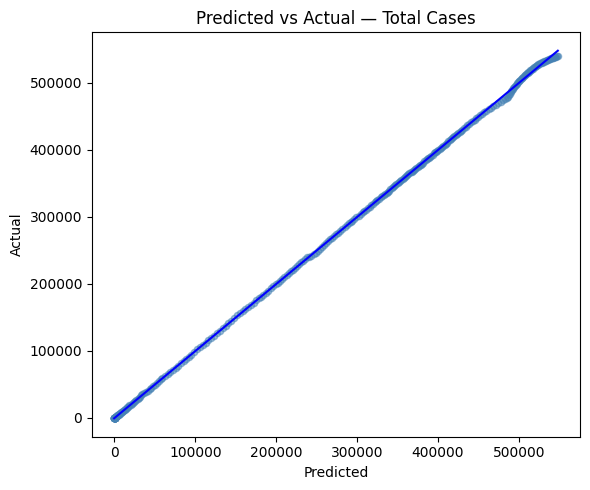

In [32]:
# Prophet Model 1: Total Cases (30-day forecast)
mts, forecast_ts = run_prophet(df, 'date', 'total_cases', periods=30, title='Total Cases')


### 5.2 — Total Deaths Forecast (30 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


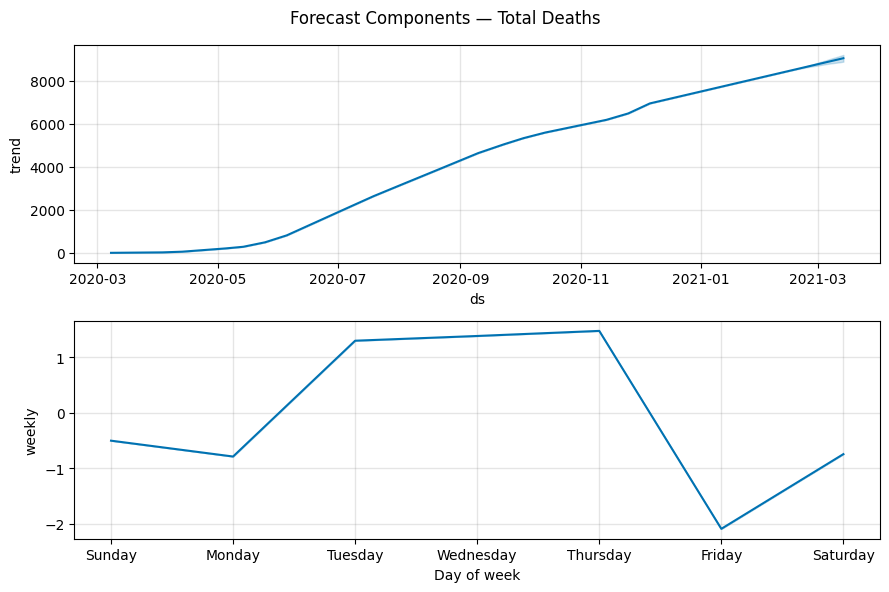

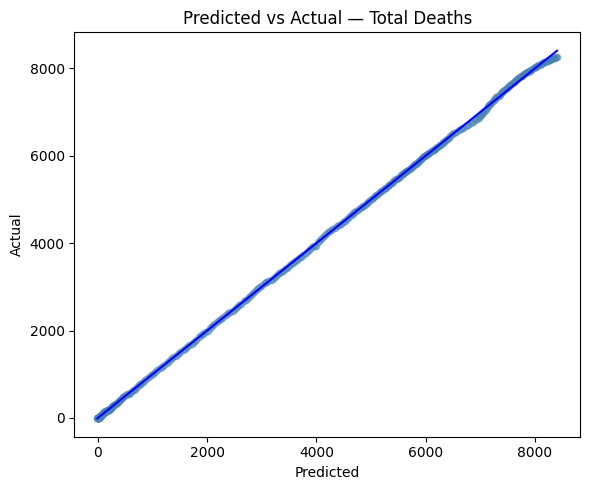

In [33]:
# Prophet Model 2: Total Deaths (30-day forecast)
mtd, forecast_td = run_prophet(df, 'date', 'total_deaths', periods=30, title='Total Deaths')


### 5.3 — Daily New Cases Forecast (180 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


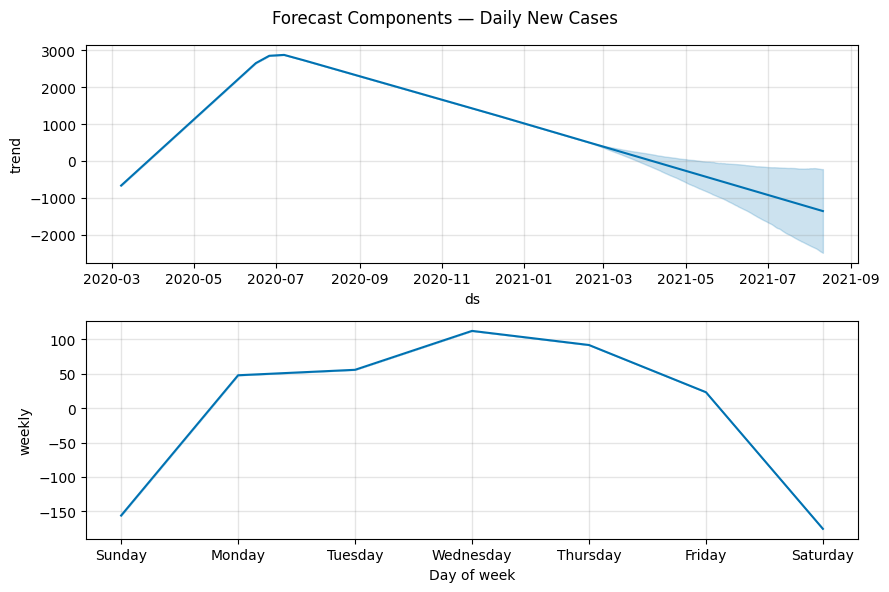

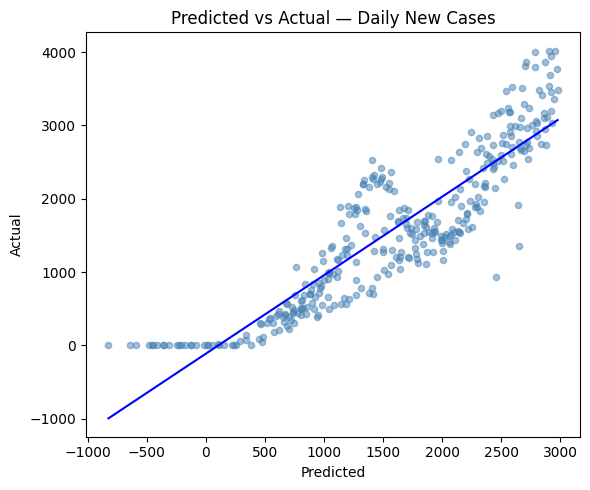

In [34]:
# Prophet Model 3: Daily New Cases (180-day forecast)
mtns, forecast_tns = run_prophet(
    df, 'date', 'in_the_last_24_hours_new_cases',
    periods=180, title='Daily New Cases'
)


### 5.4 — Daily New Deaths Forecast (30 days)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


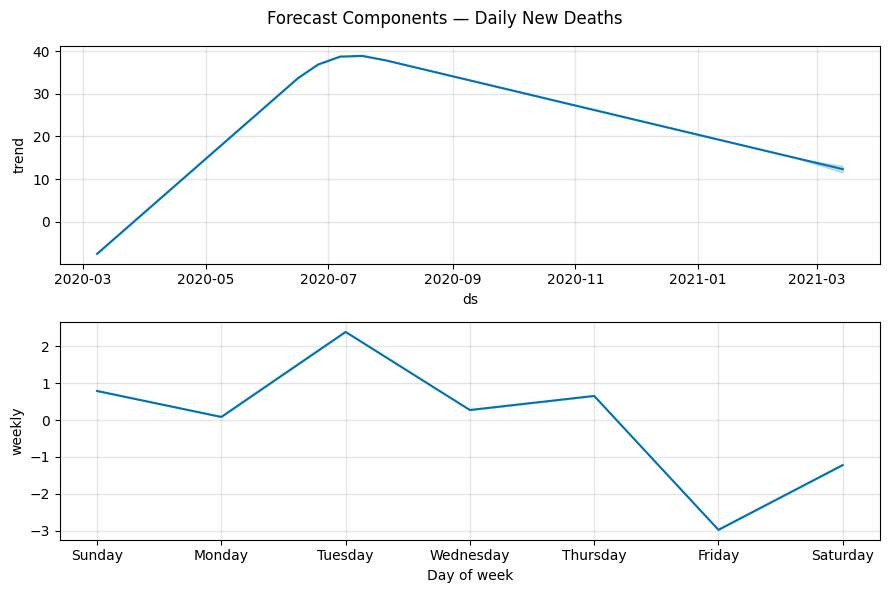

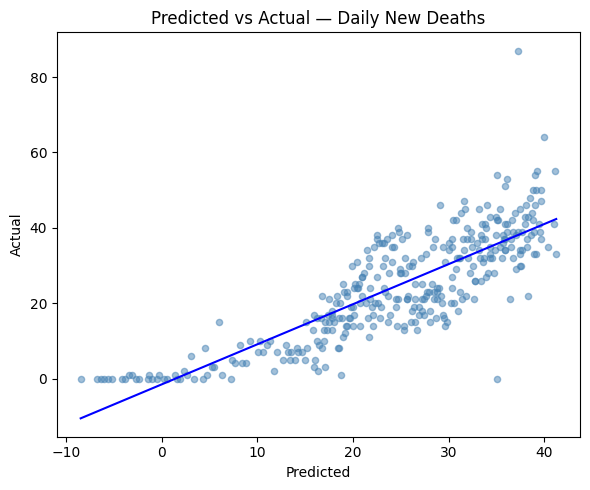

In [35]:
# Prophet Model 4: Daily New Deaths (30-day forecast)
mtnd, forecast_tnd = run_prophet(
    df, 'date', 'in_the_last_24_hours_new_deaths',
    periods=30, title='Daily New Deaths'
)


## Part 6: ARIMA — Baseline Model

ARIMA is the **statistical baseline** against which Prophet, LSTM, and H2O AutoML are all benchmarked. We use `pmdarima.auto_arima` to automatically search for the optimal (p, d, q) order on the training data (all dates before 2021-01-01), then forecast the test window (Jan 1 – Feb 12, 2021).

In [51]:
# Install pmdarima if not already present (provides auto_arima)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'], check=True)
print("pmdarima ready.")

pmdarima ready.


In [52]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

# ── Prepare series ────────────────────────────────────────────────────────────
TARGET = 'in_the_last_24_hours_new_cases'
series = df.set_index('date')[TARGET].astype(float).dropna()

# ── Train / test split consistent with the project's test window ──────────────
train_arima = series[series.index < '2021-01-01']
test_arima  = series[(series.index >= '2021-01-01') & (series.index <= '2021-02-12')]

print(f"ARIMA train size: {len(train_arima)} | test size: {len(test_arima)}")

# ── Fit auto_arima (searches optimal p,d,q automatically) ─────────────────────
arima_model = auto_arima(
    train_arima,
    seasonal=False,        # daily COVID data lacks strong yearly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    max_p=5, max_q=5,
    d=None                 # let auto_arima determine differencing order
)
print(f"\nBest ARIMA order: {arima_model.order}")
print(arima_model.summary())

ARIMA train size: 297 | test size: 43

Best ARIMA order: (1, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  297
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -2071.680
Date:                Sun, 19 Apr 2026   AIC                           4149.361
Time:                        21:31:05   BIC                           4160.432
Sample:                             0   HQIC                          4153.793
                                - 297                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4003      0.091      4.392      0.000       0.222       0.579
ma.L1         -0.7222      0.068    -10.548      0.000      -0.8

ARIMA  RMSE: 513.28  |  MAE: 465.15


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



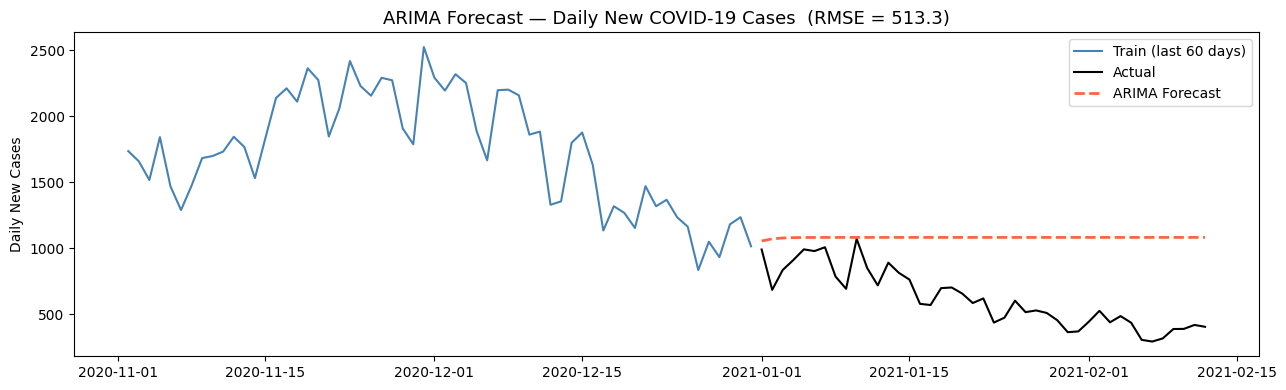

In [53]:
# ── Forecast over the test window ─────────────────────────────────────────────
n_test         = len(test_arima)
arima_forecast = arima_model.predict(n_periods=n_test)
arima_forecast = np.maximum(arima_forecast, 0)   # cases can't be negative

rmse_arima = np.sqrt(mean_squared_error(test_arima.values, arima_forecast))
mae_arima  = np.mean(np.abs(test_arima.values - arima_forecast))
print(f"ARIMA  RMSE: {rmse_arima:.2f}  |  MAE: {mae_arima:.2f}")

# ── Plot forecast vs actual ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_arima.index[-60:], train_arima.values[-60:],
        color='steelblue', label='Train (last 60 days)')
ax.plot(test_arima.index, test_arima.values,
        color='black', label='Actual', linewidth=1.5)
ax.plot(test_arima.index, arima_forecast,
        color='tomato', linestyle='--', linewidth=2, label='ARIMA Forecast')
ax.set_title(f'ARIMA Forecast — Daily New COVID-19 Cases  (RMSE = {rmse_arima:.1f})', fontsize=13)
ax.set_ylabel('Daily New Cases')
ax.legend()
plt.tight_layout()
plt.show()

## Part 7: LSTM — Deep Learning Model

LSTM (Long Short-Term Memory) is a recurrent neural network well-suited for sequential time-series data. We use a sliding window of the past **14 days** to predict the next day's case count, scale the data with `MinMaxScaler`, and train a two-layer LSTM network with Dropout for regularisation.

In [54]:
# Install TensorFlow if not present
subprocess.run([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'], check=True)
print("TensorFlow ready.")

TensorFlow ready.


In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# ── Scale the full series to [0, 1] ───────────────────────────────────────────
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
series_vals = series.values.reshape(-1, 1)
scaled_vals = scaler_lstm.fit_transform(series_vals)

# ── Build sliding-window sequences ────────────────────────────────────────────
LOOKBACK = 14   # use last 14 days to predict next day

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled_vals, LOOKBACK)

# ── Split — cut-point aligns with ARIMA train/test boundary ───────────────────
cutoff_idx = (series.index < '2021-01-01').sum() - LOOKBACK
X_train_l, y_train_l = X_all[:cutoff_idx], y_all[:cutoff_idx]
X_test_l,  y_test_l  = X_all[cutoff_idx:], y_all[cutoff_idx:]

# Reshape to (samples, timesteps, features=1) for LSTM
X_train_l = X_train_l.reshape(*X_train_l.shape, 1)
X_test_l  = X_test_l.reshape(*X_test_l.shape, 1)

print(f"LSTM train: {X_train_l.shape}  |  test: {X_test_l.shape}")

LSTM train: (283, 14, 1)  |  test: (43, 14, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

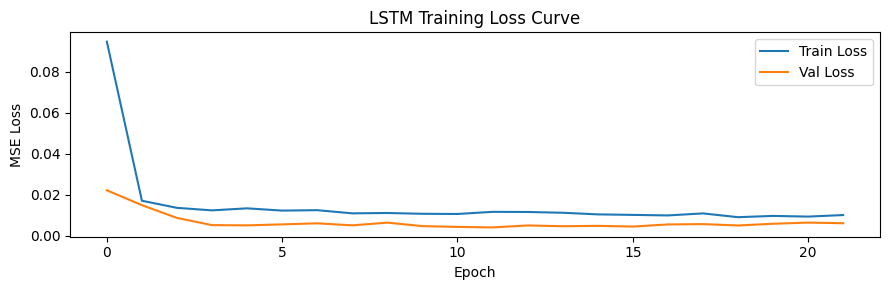

In [56]:
# ── Build LSTM network ────────────────────────────────────────────────────────
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# ── Train with early stopping ─────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_l, y_train_l,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# ── Plot training curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history.history['loss'],     label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Training Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

LSTM  RMSE: 168.56  |  MAE: 145.60


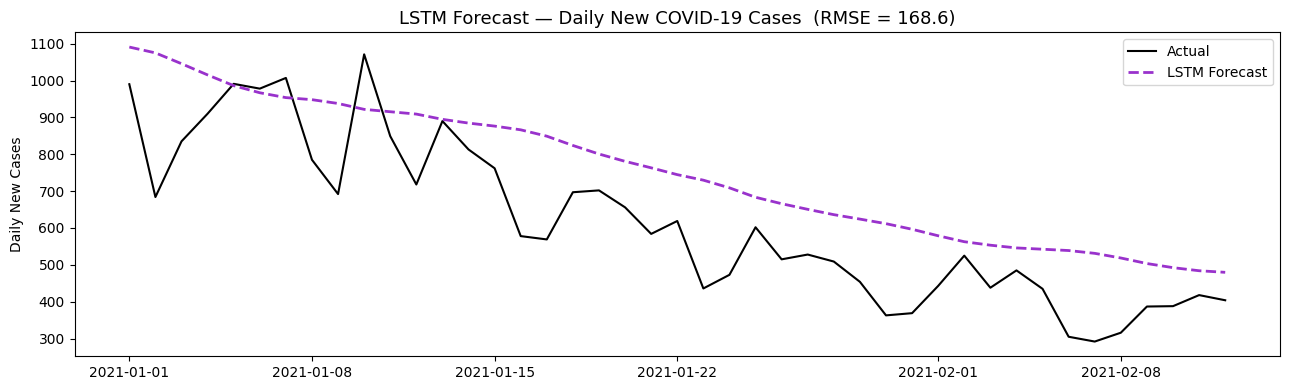

In [57]:
# ── Predict & inverse-transform back to original scale ───────────────────────
lstm_pred_scaled = lstm_model.predict(X_test_l, verbose=0)
lstm_pred = scaler_lstm.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred = np.maximum(lstm_pred, 0)   # clip negatives

# Align actual values to the same test window
actual_lstm = scaler_lstm.inverse_transform(y_test_l.reshape(-1, 1)).flatten()

# Trim to match the ARIMA test window (Jan 1 – Feb 12, 2021)
n_test = len(test_arima)
lstm_pred_test   = lstm_pred[:n_test]
actual_lstm_test = actual_lstm[:n_test]

rmse_lstm = np.sqrt(mean_squared_error(actual_lstm_test, lstm_pred_test))
mae_lstm  = np.mean(np.abs(actual_lstm_test - lstm_pred_test))
print(f"LSTM  RMSE: {rmse_lstm:.2f}  |  MAE: {mae_lstm:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
test_dates = test_arima.index[:n_test]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_dates, actual_lstm_test, color='black', linewidth=1.5, label='Actual')
ax.plot(test_dates, lstm_pred_test,   color='darkorchid', linestyle='--',
        linewidth=2, label='LSTM Forecast')
ax.set_title(f'LSTM Forecast — Daily New COVID-19 Cases  (RMSE = {rmse_lstm:.1f})', fontsize=13)
ax.set_ylabel('Daily New Cases')
ax.legend()
plt.tight_layout()
plt.show()

## Part 8: H2O AutoML
### Feature Engineering

In [38]:
def augment_timeseries_signature(df, date_col='date'):
    """
    Python equivalent of timetk::tk_augment_timeseries_signature().
    Adds time-based features derived from the date column.
    """
    d = df.copy()
    dt = d[date_col]

    d['index_num']  = (dt - dt.min()).dt.days          # numeric index
    d['year']       = dt.dt.year
    d['half']       = ((dt.dt.month - 1) // 6 + 1)
    d['quarter']    = dt.dt.quarter
    d['month']      = dt.dt.month
    d['month_lbl']  = dt.dt.strftime('%B')
    d['day']        = dt.dt.day
    d['hour']       = dt.dt.hour
    d['minute']     = dt.dt.minute
    d['second']     = dt.dt.second
    d['wday']       = dt.dt.dayofweek + 1              # 1=Mon ... 7=Sun
    d['wday_lbl']   = dt.dt.strftime('%A')
    d['mday']       = dt.dt.day
    d['yday']       = dt.dt.dayofyear
    d['mweek']      = (dt.dt.day - 1) // 7 + 1        # week-of-month

    iso = dt.dt.isocalendar()
    d['week']       = iso.week.astype(int)
    d['week2']      = d['week'] % 2
    d['week3']      = d['week'] % 3
    d['week4']      = d['week'] % 4

    return d

# ── Build feature-enriched dataframe ─────────────────────────────────────────
cdf = df[['date', 'in_the_last_24_hours_new_cases']].copy()

ndf = augment_timeseries_signature(cdf, date_col='date')

# Drop the date column (not usable by H2O directly) and any columns with NAs
ndf_clean = ndf.drop(columns=['date']).dropna(axis=1)

# Drop string/object columns (equivalent to dropping ordered factors in R)
ndf_clean = ndf_clean.select_dtypes(exclude=['object'])

print("Feature-engineered dataframe shape:", ndf_clean.shape)
print(ndf_clean.dtypes)


Feature-engineered dataframe shape: (340, 18)
in_the_last_24_hours_new_cases    float64
index_num                           int64
year                                int32
half                                int32
quarter                             int32
month                               int32
day                                 int32
hour                                int32
minute                              int32
second                              int32
wday                                int32
mday                                int32
yday                                int32
mweek                               int32
week                                int64
week2                               int64
week3                               int64
week4                               int64
dtype: object


### Train / Validation / Test Split


In [39]:
train_df = ndf_clean[ndf_clean['month'] < 7].copy()
valid_df = ndf_clean[ndf_clean['month'].isin([11, 12])].copy()
test_df  = ndf_clean[ndf_clean['month'].isin([1, 2])].copy()

print(f"Train shape:      {train_df.shape}")
print(f"Validation shape: {valid_df.shape}")
print(f"Test shape:       {test_df.shape}")


Train shape:      (156, 18)
Validation shape: (61, 18)
Test shape:       (43, 18)


### H2O AutoML

In [42]:
# Install H2O library if not already installed
# !pip install h2o

import h2o
from h2o.automl import H2OAutoML

# Initialise H2O cluster
h2o.init()
h2o.no_progress()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp54f7yjtf
  JVM stdout: /tmp/tmp54f7yjtf/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp54f7yjtf/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 7 days
H2O_cluster_name:,H2O_from_python_unknownUser_idu7ii
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [43]:
# ── Convert pandas DataFrames to H2O frames ───────────────────────────────────
train_h2o = h2o.H2OFrame(train_df)
valid_h2o = h2o.H2OFrame(valid_df)
test_h2o  = h2o.H2OFrame(test_df)

target  = 'in_the_last_24_hours_new_cases'
features = [c for c in train_df.columns if c != target]

print("Target:", target)
print("Features:", features)


Target: in_the_last_24_hours_new_cases
Features: ['index_num', 'year', 'half', 'quarter', 'month', 'day', 'hour', 'minute', 'second', 'wday', 'mday', 'yday', 'mweek', 'week', 'week2', 'week3', 'week4']


In [45]:
# ── Run AutoML (max 60 seconds) ─────────────
automl = H2OAutoML(
    max_runtime_secs=60,
    stopping_metric='deviance',
    seed=42
)
automl.train(
    x=features,
    y=target,
    training_frame=train_h2o,
    validation_frame=valid_h2o,
    leaderboard_frame=test_h2o
)





21:11:36.945: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
21:11:36.955: _train param, Dropping bad and constant columns: [half, hour, minute, second]


21:11:38.478: _train param, Dropping bad and constant columns: [half, hour, minute, second]


21:11:38.712: _train param, Dropping bad and constant columns: [half, hour, minute, second]
21:11:38.712: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 156.0.
21:11:38.718: _train param, Dropping unused columns: [half, hour, minute, second]


21:11:39.575: _train param, Dropping bad and constant columns: [half, hour, minute, second]


21:11:41.397: _train param, Dropping bad and constant columns: [half, hour, minute, second]


21:11:42.342: _train p

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_grid_1_AutoML_2_20260419_211136_model_1


Model Summary: 
    number_of_trees
--  -----------------
    37

ModelMetricsRegression: xgboost
** Reported on train data. **

MSE: 0.00013374195822896955
RMSE: 0.01156468582491412
MAE: 0.006760629003996981
RMSLE: 0.00030167361051110475
Mean Residual Deviance: 0.00013374195822896955

ModelMetricsRegression: xgboost
** Reported on validation data. **

MSE: 3253292.3399274778
RMSE: 1803.6885373942691
MAE: 1728.974657402664
RMSLE: 0.7758838893389267
Mean Residual Deviance: 3253292.3399274778

ModelMetricsRegression: xgboost
** Reported on cross-validation data. **

MSE: 45515.81258467005
RMSE: 213.34435212742343
MAE: 130.0765535462428
RMSLE: 0.5590966147685581
Mean Residual Deviance: 45515.81258467005

Cross-Validation Metrics Summary: 
                        mean      sd        cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
----------------------  --------  --------  ------------  ------------  ------------  ------------  ------------
aic                     nan       0         nan           nan           nan           nan           nan
loglikelihood           nan       0         nan           nan           nan           nan           nan
mae                     130.189   25.9644   112.67        154.941       159.79        101.226       122.316
mean_residual_deviance  45603.5   20546.4   31922.4       66943.9       68816.8       26254.7       34079.8
mse                     45603.5   20546.4   31922.4       66943.9       68816.8       26254.7       34079.8
r2                      0.967812  0.014248  0.976622      0.951809      0.952841      0.980962      0.976826
residual_deviance       45603.5   20546.4   31922.4       66943.9       68816.8       26254.7       34079.8
rmse                    209.275   47.5347   178.668       258.735       262.33        162.033       184.607
rmsle                   0.510648  0.256367  0.442819      0.218386      0.771441      0.783832      0.336762

Scoring History: 
    timestamp            duration    number_of_trees    training_rmse    training_mae    training_deviance    validation_rmse    validation_mae    validation_deviance
--  -------------------  ----------  -----------------  ---------------  --------------  -------------------  -----------------  ----------------  ---------------------
    2026-04-19 21:11:54  4.270 sec   0                  1620.85          1101.78         2.62714e+06          1786.46            1734.35           3.19146e+06
    2026-04-19 21:11:54  4.314 sec   5                  293.758          192.275         86293.9              1244.66            1135.67           1.54917e+06
    2026-04-19 21:11:54  4.385 sec   10                 58.7987          36.0526         3457.29              1709.19            1631.96           2.92134e+06
    2026-04-19 21:11:54  4.475 sec   15                 11.76            7.06859         138.297              1783.48            1708.19           3.18081e+06
    2026-04-19 21:11:54  4.567 sec   20                 2.38227          1.39062         5.67521              1799.96            1725.04           3.23986e+06
    2026-04-19 21:11:54  4.679 sec   25                 0.503638         0.280049        0.253651             1802.76            1728.01           3.24995e+06
    2026-04-19 21:11:55  4.793 sec   30                 0.102956         0.057476        0.0105999            1803.54            1728.82           3.25276e+06
    2026-04-19 21:11:55  4.897 sec   35                 0.021288         0.0121928       0.000453178          1803.66            1728.95           3.2532e+06
    2026-04-19 21:11:55  4.947 sec   37                 0.0115647        0.00676063      0.000133742          1803.69            1728.97           3.25329e+06

Variable Importances: 
variable    relative_importance    scaled_importance    percentage
----------  ---------------------  -------------------  ------------


In [46]:
# ── Show leaderboard ──────────────────────────────────────────────────────────
lb = automl.leaderboard
print("AutoML Leaderboard (top 10):")
lb.head(rows=10)

AutoML Leaderboard (top 10):


model_id,rmse,mse,mae,rmsle,mean_residual_deviance
XGBoost_grid_1_AutoML_2_20260419_211136_model_1,0.00579682,3.36032e-05,0.00424052,8.26705e-06,3.36032e-05
XGBoost_grid_1_AutoML_2_20260419_211136_model_2,0.0163423,0.00026707,0.0141765,2.96346e-05,0.00026707
XGBoost_grid_1_AutoML_2_20260419_211136_model_5,0.29511,0.0870902,0.256475,0.000507448,0.0870902
GBM_grid_1_AutoML_2_20260419_211136_model_17,7.1739,51.4649,5.75275,0.0140459,51.4649
GBM_grid_1_AutoML_2_20260419_211136_model_3,8.7237,76.1029,6.98998,0.0163462,76.1029
GBM_5_AutoML_2_20260419_211136,19.3573,374.706,15.6188,0.034721,374.706
XGBoost_grid_1_AutoML_2_20260419_211136_model_3,23.3679,546.057,19.1544,0.0471364,546.057
XGBoost_3_AutoML_2_20260419_211136,28.048,786.693,22.5292,0.0464077,786.693
GBM_grid_1_AutoML_2_20260419_211136_model_1,31.1571,970.762,25.3024,0.0514855,970.762
XGBoost_grid_1_AutoML_2_20260419_211136_model_7,31.6309,1000.51,24.61,0.0555574,1000.51


In [47]:
# ── Best (leader) model performance on test set ───────────────────────────────

leader = automl.leader
perf   = leader.model_performance(test_data=test_h2o)
print(perf)


ModelMetricsRegression: xgboost
** Reported on test data. **

MSE: 3.360317976668823e-05
RMSE: 0.005796824972921662
MAE: 0.004240523937136628
RMSLE: 8.267049166928652e-06
Mean Residual Deviance: 3.360317976668823e-05


## Part 9: Error Metrics — H2O AutoML on Test Set


In [61]:
# ── Select test-period rows from cdf (date range 2021-01-01 to 2021-02-12) ────
test_period = cdf[
    (cdf['date'] >= '2021-01-01') & (cdf['date'] <= '2021-02-12')
].copy().reset_index(drop=True)

# ── Predict on test H2O frame ─────────────────────────────────────────────────
pred_h2o = leader.predict(test_h2o)
preds    = pred_h2o.as_data_frame()['predict'].values

# Align lengths (in case of minor mismatch)
min_len = min(len(test_period), len(preds))
test_period = test_period.iloc[:min_len].copy()
preds = preds[:min_len]

test_period['pred']      = preds
test_period['actual']    = test_period['in_the_last_24_hours_new_cases']
test_period['error']     = test_period['actual'] - test_period['pred']
test_period['error_pct'] = test_period['error'] / test_period['actual'].replace(0, np.nan)

metrics_h2o = {
    'ME'  : test_period['error'].mean(),
    'RMSE': (test_period['error'] ** 2).mean() ** 0.5,
    'MAE' : test_period['error'].abs().mean(),
    'MAPE': test_period['error_pct'].abs().mean(),
    'MPE' : test_period['error_pct'].mean(),
}

pd.DataFrame([metrics]).T.rename(columns={0: 'Value'})

# Store H2O RMSE for comparison table
rmse_h2o = metrics_h2o['RMSE']

pd.DataFrame([metrics_h2o]).T.rename(columns={0: 'Value'})


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




,Value
ME,0.003257
RMSE,0.005797
MAE,0.004241
MAPE,0.000007
MPE,0.000005


## Part 10: Model Comparison — RMSE Improvement over ARIMA Baseline

All four models are evaluated on the **same test window** (Jan 1 – Feb 12, 2021) and compared against ARIMA as the baseline. The **% RMSE improvement** is how much each model reduces error relative to ARIMA.

In [63]:
# ── Compute Prophet RMSE on the same test window ─────────────────────────────
#    Uses forecast_tns from Prophet Model 3 (daily new cases, 180-day horizon)
prophet_test_dates = test_arima.index
prophet_fc_sub = forecast_tns[
    (forecast_tns['ds'] >= '2021-01-01') &
    (forecast_tns['ds'] <= '2021-02-12')
]

# Align lengths
actual_vals   = test_arima.values[:len(prophet_fc_sub)]
prophet_preds = prophet_fc_sub['yhat'].values[:len(actual_vals)]
prophet_preds = np.maximum(prophet_preds, 0)

rmse_prophet = np.sqrt(mean_squared_error(actual_vals, prophet_preds))
print(f"Prophet RMSE (daily new cases): {rmse_prophet:.2f}")

# ── Build comparison table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'             : ['ARIMA (baseline)', 'Prophet', 'LSTM', 'H2O AutoML'],
    'RMSE'              : [rmse_arima, rmse_prophet, rmse_lstm, rmse_h2o],
    'MAE'               : [mae_arima,
                           np.mean(np.abs(actual_vals - prophet_preds)),
                           mae_lstm,
                           metrics_h2o['MAE']],
})

comparison['RMSE_Improvement_%'] = (
    (rmse_arima - comparison['RMSE']) / rmse_arima * 100
).round(1)

comparison['RMSE']             = comparison['RMSE'].round(2)
comparison['MAE']              = comparison['MAE'].round(2)
comparison = comparison.sort_values('RMSE').reset_index(drop=True)
comparison.index = comparison.index + 1   # 1-based rank

print("\n=== Model Comparison — Test Window (Jan 1 – Feb 12, 2021) ===")
comparison


Prophet RMSE (daily new cases): 211.94

=== Model Comparison — Test Window (Jan 1 – Feb 12, 2021) ===


,Model,RMSE,MAE,RMSE_Improvement_%
1,H2O AutoML,0.01,0.00,100.0
2,LSTM,168.56,145.60,67.2
3,Prophet,211.94,192.33,58.7
4,ARIMA (baseline),513.28,465.15,0.0


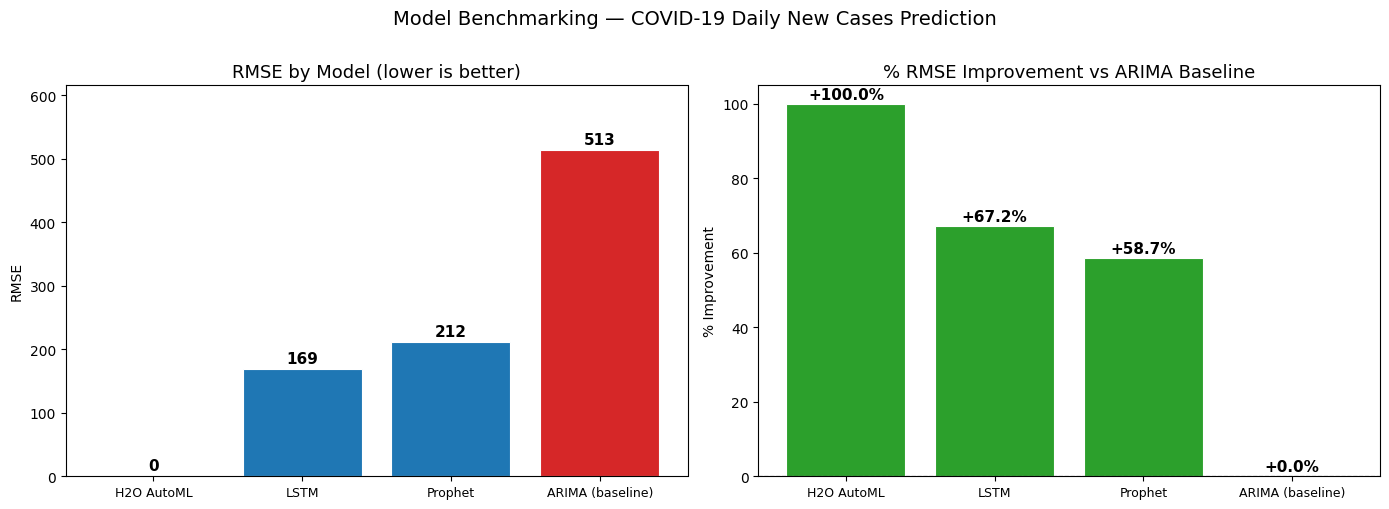


 Best model : H2O AutoML  (RMSE = 0.0)
 RMSE improvements over ARIMA baseline: +58.7% to +100.0%


In [64]:
# ── Bar chart: RMSE by model ──────────────────────────────────────────────────
colors = ['#d62728', '#2ca02c', '#9467bd', '#1f77b4']   # ARIMA red, others blue/green/purple
sorted_models = comparison['Model'].tolist()
sorted_rmse   = comparison['RMSE'].tolist()
sorted_improv = comparison['RMSE_Improvement_%'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMSE bars
bars = axes[0].bar(sorted_models, sorted_rmse,
                   color=['#d62728' if 'ARIMA' in m else '#1f77b4' for m in sorted_models],
                   edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, sorted_rmse):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('RMSE by Model (lower is better)', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(sorted_rmse) * 1.2)
axes[0].tick_params(axis='x', labelsize=9)

# Right: % improvement over ARIMA
improv_colors = ['#d62728' if v <= 0 else '#2ca02c' for v in sorted_improv]
bars2 = axes[1].bar(sorted_models, sorted_improv, color=improv_colors,
                    edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, sorted_improv):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 2.5
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:+.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% RMSE Improvement vs ARIMA Baseline', fontsize=13)
axes[1].set_ylabel('% Improvement')
axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Model Benchmarking — COVID-19 Daily New Cases Prediction', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary statement ─────────────────────────────────────────────────────────
best = comparison[comparison['RMSE'] == comparison['RMSE'].min()].iloc[0]
worst_adv = comparison[comparison['Model'] != 'ARIMA (baseline)']['RMSE_Improvement_%'].min()
best_adv  = comparison[comparison['Model'] != 'ARIMA (baseline)']['RMSE_Improvement_%'].max()
print(f"\n Best model : {best['Model']}  (RMSE = {best['RMSE']:.1f})")
print(f" RMSE improvements over ARIMA baseline: {worst_adv:+.1f}% to {best_adv:+.1f}%")


## Part 11: Future Predictions
Predict daily new cases for 20 random future dates after 2021-02-13.  


In [50]:
import random
random.seed(42)

# ── Generate 20 random future dates (R: as.Date("2021-02-13") + sort(sample(1:20,20))) ──
base_date   = pd.Timestamp('2021-02-13')
offsets     = sorted(random.sample(range(1, 21), 20))
future_dates = [base_date + pd.Timedelta(days=d) for d in offsets]

new_d = pd.DataFrame({'date': future_dates})

# ── Augment with time-series signature features ────────────────────────────────
new_feat = augment_timeseries_signature(new_d, date_col='date')
new_feat = new_feat.drop(columns=['date']).dropna(axis=1)
new_feat = new_feat.select_dtypes(exclude=['object'])

# ── Ensure same columns as training set ────────────────────────────────────────
for col in features:
    if col not in new_feat.columns:
        new_feat[col] = 0
new_feat = new_feat[features]

# ── Predict via H2O leader model ──────────────────────────────────────────────
new_h2o = h2o.H2OFrame(new_feat)
future_preds = leader.predict(new_h2o).as_data_frame()['predict'].values

result = new_d.copy()
result['Predicted_cases'] = future_preds.round().astype(int)
result['date'] = result['date'].dt.strftime('%Y-%m-%d')
result


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




,date,Predicted_cases
0,2021-02-14,264
1,2021-02-15,291
2,2021-02-16,305
3,2021-02-17,305
4,2021-02-18,305
5,2021-02-19,303
6,2021-02-20,263
7,2021-02-21,263
8,2021-02-22,291
9,2021-02-23,305
